# Analyse par ingrédient de l'erreur glucidique — Nutrition5k

**Ce que fait ce notebook.** Le papier établit que l'erreur du modèle visuel est dominée par la
*composition* (densité par gramme) et non par la *portion*, et qu'un modèle visuel n'égale qu'un
prédicteur recevant l'identité des ingrédients et la masse totale (P1b). Ces constats sont globaux :
ils disent *qu'il* manque de l'information, pas *laquelle* ni *où*.

Ce notebook ouvre cette boîte noire en descendant au niveau de l'ingrédient. Il établit quatre points :

1. **L'anomalie des féculents** — sur les plats où riz/pâtes/pain/céréales dominent, le modèle estime
   la masse correctement mais sous-estime les glucides de ~27 %. Le biais est présent **sans image**
   et ne disparaît **qu'avec les masses par ingrédient** : c'est une limite d'information, incarnée
   dans une classe d'aliments nommable.
2. **Le gradient composition/portion** — la part « composition » de l'erreur passe de 54 % sur les
   plats mono-ingrédient à 69 % sur les plats composés. La domination de la composition est *produite
   par le mélange*.
3. **La compression opère au niveau des types d'aliments** — la densité glucidique implicite du
   modèle est compressée d'un facteur 0,72, ce qui explique mécaniquement la pente de sortie de 0,78.
4. **Le nombre d'ingrédients est un faux coupable** — sa corrélation avec l'erreur est entièrement un
   effet de masse.

**Données.** Prédictions par plat déjà calculées (`CNN/resultats/`, `Transformers/resultats/`,
`CNN/baseline_results/`) et métadonnées ingrédient de Nutrition5k. Aucun GPU, aucun réentraînement.

## 0. Mise en place

### Périmètre des données : ce que les deux dorsales ont en commun

`CNN/resultats/` et `Transformers/resultats/` ne contiennent pas exactement les mêmes fichiers.
Pour que la comparaison CNN ↔ Swin soit **strictement symétrique**, ce notebook n'utilise que
l'intersection : les **16 CSV bruts du plan factoriel**, présents des deux côtés, sur le
**test officiel complet de 507 plats**.

Sont volontairement **exclus** :

- les fichiers `_filtered` (497 plats, les 10 « non convenables » retirés) — ils n'existent que
  côté Swin pour le factoriel ;
- les campagnes multi-graines `_s0`…`_s4` — elles n'existent que côté CNN.

Tout résultat de ce notebook est donc obtenu sur **un run unique par variante**, avec exactement
les mêmes fichiers et le même jeu de plats pour les deux dorsales. Aucune barre d'erreur ne provient
de graines : la robustesse est établie par la **réplication sur les 32 variantes** du plan factoriel
(2 dorsales × 2 profondeurs × 4 alignements FLAVA × 2 têtes), qui sont 32 entraînements indépendants.

*Seule exception, signalée sur place :* le § 2 compare le modèle visuel aux baselines sans image, qui
n'ont été produites que sur 497 plats. Cette section aligne donc les deux sur leurs plats communs —
la même restriction s'appliquant à l'identique à CNN et à Swin.

### Note sur la tête densité

Les exports de la tête densité côté CNN ne contiennent pas les colonnes `preddens_*` / `truedens_*`,
contrairement à ceux de Swin. Ce n'est pas bloquant : `eval.py` écrit
$\text{pred\_carb} = d_p \times \text{pred\_mass}/100$, donc la densité prédite se **reconstruit
exactement** par $d_p = 100 \times \text{pred\_carb}/\text{pred\_mass}$ (vérifié plus bas au
$10^{-4}$ près contre les colonnes stockées de Swin). Le § 3 utilise cette reconstruction et reste
donc symétrique.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge, LinearRegression

PROJ  = Path.cwd()
META  = PROJ / "data/nutrition5k/metadata/dish_metadata_cafe1.csv"
SPLIT = PROJ / "data/nutrition5k/dish_ids/splits"
RES   = {"CNN": PROJ / "CNN/resultats", "Swin": PROJ / "Transformers/resultats"}
BASE  = PROJ / "CNN/baseline_results"
NUTR  = ["calories", "mass", "fat", "carb", "protein"]

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREY = "#3b6ea5", "#d1702f", "#9a9a9a"
print("racine du projet :", PROJ)

racine du projet : /Users/lubin/Documents/Flava/cluster_files/Fusion_Midas_Flava


### Lecture des métadonnées

`dish_metadata_cafe1.csv` est un CSV *ragged* : 6 champs de plat
(`dish_id`, calories, masse, lipides, glucides, protéines) suivis d'un nombre variable de groupes de
7 champs par ingrédient (`id`, nom, grammes, calories, lipides, glucides, protéines). Le nombre de
colonnes vaut donc $6 + 7k$ pour $k$ ingrédients.

In [2]:
def parse_dishes(path=META):
    dishes = {}
    for line in open(path):
        f = line.rstrip("\n").split(",")
        if len(f) < 13 or (len(f) - 6) % 7:
            continue
        d = {n: float(f[1 + i]) for i, n in enumerate(NUTR)}
        d["ingredients"] = [
            {"name": f[k + 1].strip(), "grams": float(f[k + 2]), "carb": float(f[k + 5])}
            for k in range(6, len(f), 7)
        ]
        dishes[f[0]] = d
    return dishes

DISHES = parse_dishes()
print(f"{len(DISHES)} plats lus depuis les métadonnées")

# Contrôle d'intégrité : la somme des glucides par ingrédient doit reconstituer le total du plat.
ecart = max(abs(sum(i["carb"] for i in d["ingredients"]) - d["carb"]) for d in DISHES.values())
print(f"écart max somme(glucides ingrédients) vs total du plat : {ecart:.2e} g")

4768 plats lus depuis les métadonnées
écart max somme(glucides ingrédients) vs total du plat : 8.82e-05 g


### Taxonomie des ingrédients

197 ingrédients distincts apparaissent dans le train, ce qui est trop pour une attribution stable
sur 497 plats de test — et les plats de Nutrition5k étant construits par ajout incrémental, les
ingrédients co-apparaissent par blocs fortement corrélés. On les regroupe donc en types.

**Point de méthode :** la taxonomie est définie par mots-clés *a priori*, sans jamais regarder les
erreurs du modèle. La regarder reviendrait à ajuster la grille de lecture aux données sur lesquelles
on conclut.

Le groupe critique est `feculent` (riz, pâtes, pain, céréales). Il est **volontairement distinct** de
`tubercule` (pomme de terre, patate douce, igname), tout aussi féculent sur le plan nutritionnel :
ce contraste sert de contrôle de spécificité au § 1.

In [3]:
RULES = [
 ("pizza",        ["pizza"]),
 ("feculent",     ["rice","quinoa","wheat berry","pasta","spaghetti","penne","macaroni","noodle",
                   "bread","bagel","toast","bun","roll","couscous","barley","oat","cereal","granola",
                   "tortilla","pita","crouton","cracker","biscuit","stuffing","pancake","waffle",
                   "grits","polenta","millet","bulgur","pilaf","flour","chilaquiles","sandwich"]),
 ("tubercule",    ["potato","yam","hash brown","fries","tater"]),
 ("legumineuse",  ["bean","lentil","chickpea","hummus","pea ","peas","edamame","tofu","falafel","tempeh"]),
 ("fruit",        ["berr","apple","grape","pineapple","pear","watermelon","cantaloupe","melon","banana",
                   "orange","mango","peach","plum","cherr","kiwi","fruit","raisin","date","fig",
                   "apricot","papaya","avocado"]),
 ("legume",       ["broccoli","carrot","cauliflower","brussels","tomato","lettuce","spinach","pepper",
                   "onion","cucumber","zucchini","mushroom","olive","celery","asparagus","green bean",
                   "corn","cabbage","kale","squash","eggplant","artichoke","radish","beet","salad",
                   "arugula","sprout","leek","okra","pickle","coleslaw","veget","mixed greens",
                   "bok choy","chard","tatsoi","turnip","parsnip"]),
 ("noix_graine",  ["almond","walnut","peanut","cashew","pecan","pistachio","seed","nut"]),
 ("viande_poisson",["chicken","beef","pork","turkey","ham","bacon","salmon","tuna","shrimp","fish",
                   "sausage","steak","meatball","lamb","duck","crab","lobster","meat","brisket","pastrami"]),
 ("oeuf",         ["egg"]),
 ("laitier",      ["cheese","milk","yogurt","yoghurt","cream","ricotta","mozzarella","feta","parmesan"]),
 ("sucre_dessert",["sugar","chocolate","cookie","cake","brownie","ice cream","candy","dessert","pie",
                   "muffin","donut","syrup","honey","jam","jelly","pudding","frosting","marshmallow"]),
 ("sauce_condiment",["sauce","dressing","ketchup","mayo","mustard","salsa","vinaigrette","guacamole",
                   "gravy","pesto","relish","dip","vinegar","marinade"]),
 ("matiere_grasse",["oil","butter","margarine","lard"]),
 ("herbe_epice",  ["salt","pepper corn","parsley","basil","cilantro","oregano","thyme","rosemary",
                   "garlic","ginger","cinnamon","spice","herb","chive","dill","mint","cumin",
                   "paprika","seasoning"]),
 ("boisson",      ["juice","soda","coffee","tea","water","smoothie","wine","beer"]),
]

def ingr_type(name):
    n = name.lower().strip()
    for t, keys in RULES:
        if any(k in n for k in keys):
            return t
    return "autre"

TYPES = sorted({t for t, _ in RULES} | {"autre"})

# Grammes par type, et descripteurs de plat, pour chaque plat.
TYPE_G, NINGR, DISP = {}, {}, {}
for did, d in DISHES.items():
    ings = [i for i in d["ingredients"] if i["grams"] > 0]
    v = {}
    for i in ings:
        v[ingr_type(i["name"])] = v.get(ingr_type(i["name"]), 0.0) + i["grams"]
    TYPE_G[did] = v
    NINGR[did]  = len(ings)
    if ings:
        g = np.array([i["grams"] for i in ings]); c = np.array([i["carb"] for i in ings])
        w = g / g.sum(); dens = c / g * 100.0
        DISP[did] = float(np.sqrt((w * (dens - (w * dens).sum()) ** 2).sum()))
    else:
        DISP[did] = 0.0

# Couverture de la taxonomie, mesurée sur le TRAIN et pondérée par les glucides.
train_ids = {l.strip() for l in open(SPLIT / "depth_train_ids.txt") if l.strip()}
cov = {}
for did in train_ids & set(DISHES):
    for i in DISHES[did]["ingredients"]:
        if i["grams"] > 0:
            cov[ingr_type(i["name"])] = cov.get(ingr_type(i["name"]), 0.0) + i["carb"]
tot = sum(cov.values())
print(f"glucides du train non classés : {cov.get('autre', 0)/tot*100:.1f} %")
print("\npart des glucides du train par type :")
for t, v in sorted(cov.items(), key=lambda x: -x[1])[:8]:
    print(f"  {t:16s} {v/tot*100:5.1f} %")

glucides du train non classés : 0.4 %

part des glucides du train par type :
  legume            21.6 %
  fruit             20.7 %
  feculent          19.8 %
  pizza             15.0 %
  tubercule         12.3 %
  noix_graine        2.7 %
  legumineuse        2.2 %
  sucre_dessert      1.5 %


### Chargement des prédictions et validation

Le factoriel CNN n'existe qu'en version brute (507 plats). On applique le filtre `dishes_to_skip.txt`
pour obtenir les 497 plats du papier. La cellule suivante **vérifie** que ce refiltrage est correct,
de deux façons indépendantes : identité exacte des plats avec les `_filtered` de Swin, et
reproduction des chiffres publiés de la Table 1 (CNN / GT / sans FLAVA : glucides 19,63 %,
masse 8,52 %).

In [4]:
FACTORIEL = [f"fusion_{dep}{fl}_all{h}_best"
             for dep in ("gt", "midas") for fl in ("", "_ft", "_fv", "_ftv") for h in ("", "_d")]

def load(stem, backbone="CNN"):
    # CSV BRUT (507 plats) : le seul format present des deux cotes. On n'utilise
    # ni les _filtered (Swin seulement) ni les graines (CNN seulement).
    df = pd.read_csv(RES[backbone] / f"{stem}.csv")
    sh_f = np.array([TYPE_G[x].get("feculent", 0.0) for x in df.dish_id]) / df.true_mass.values
    sh_t = np.array([TYPE_G[x].get("tubercule", 0.0) for x in df.dish_id]) / df.true_mass.values
    return df.assign(part_feculent=sh_f, part_tubercule=sh_t,
                     err=df.pred_carb - df.true_carb, abserr=(df.pred_carb - df.true_carb).abs(),
                     err_mass=df.pred_mass - df.true_mass,
                     n_ingr=[NINGR[x] for x in df.dish_id], disp=[DISP[x] for x in df.dish_id])

def pmae(df, col="carb"):
    return (df[f"pred_{col}"] - df[f"true_{col}"]).abs().mean() / df[f"true_{col}"].mean() * 100

cnn  = load("fusion_gt_all_best", "CNN")
swin = load("fusion_gt_all_best", "Swin")
print(f"CNN n={len(cnn)} | Swin n={len(swin)} | mêmes plats, même ordre : "
      f"{list(cnn.dish_id) == list(swin.dish_id)}")
manquants = [(bb, v) for bb in ("CNN", "Swin") for v in FACTORIEL
             if not (RES[bb] / f"{v}.csv").is_file()]
print(f"variantes du factoriel manquantes : {manquants if manquants else 'aucune (16/16 des deux côtés)'}")

print(f"\nTest complet (n=507) — CNN / GT / sans FLAVA : glucides {pmae(cnn):.2f} %, "
      f"masse {pmae(cnn,'mass'):.2f} %")
print(f"Test complet (n=507) — Swin / GT / sans FLAVA : glucides {pmae(swin):.2f} %")
print("\nRappel : le papier rapporte le test filtré (n=497, glucides 19,63 CNN / 19,90 Swin).")
print("Les valeurs ci-dessus sont sur 507 plats, donc ~0,5 pt plus hautes. C'est attendu :")
print("ce notebook privilégie la symétrie CNN/Swin au raccord avec les tableaux du papier.")

# Vérification de la reconstruction des densités (cf. § 0), là où Swin stocke les deux.
v = pd.read_csv(RES["Swin"] / "fusion_gt_all_d_best.csv")
e = (v.pred_carb / v.pred_mass * 100 - v.preddens_carb).abs().max()
print(f"\nreconstruction de la densité prédite : écart max {e:.1e} g/100 g")

CNN n=507 | Swin n=507 | mêmes plats, même ordre : True
variantes du factoriel manquantes : aucune (16/16 des deux côtés)

Test complet (n=507) — CNN / GT / sans FLAVA : glucides 20.20 %, masse 9.38 %
Test complet (n=507) — Swin / GT / sans FLAVA : glucides 20.39 %

Rappel : le papier rapporte le test filtré (n=497, glucides 19,63 CNN / 19,90 Swin).
Les valeurs ci-dessus sont sur 507 plats, donc ~0,5 pt plus hautes. C'est attendu :
ce notebook privilégie la symétrie CNN/Swin au raccord avec les tableaux du papier.

reconstruction de la densité prédite : écart max 1.2e-04 g/100 g


---
## 1. L'anomalie des féculents

On appelle « plat à féculent » un plat dont le riz, les pâtes, le pain ou les céréales représentent
au moins 25 % de la masse totale. Ils sont 32 sur les 497 du test, soit 6 %.

Le tableau ci-dessous oppose, sur ces plats, l'erreur de **masse** et l'erreur de **glucides**.

In [5]:
def strates(df):
    return [("féculent ≥ 25 % de la masse", df[df.part_feculent >= .25]),
            ("tubercule ≥ 25 % de la masse", df[df.part_tubercule >= .25]),
            ("ni l'un ni l'autre", df[(df.part_feculent == 0) & (df.part_tubercule == 0)])]

rows = []
for bb, df in (("CNN", cnn), ("Swin", swin)):
    for lab, s in strates(df):
        rows.append({"backbone": bb, "strate": lab, "n": len(s),
                     "err_masse_%": s.err_mass.mean() / s.true_mass.mean() * 100,
                     "err_glucides_%": s.err.mean() / s.true_carb.mean() * 100})
tab1 = pd.DataFrame(rows)
display(tab1.round(1))

,backbone,strate,n,err_masse_%,err_glucides_%
0,CNN,féculent ≥ 25 % de la masse,33,0.7,-28.7
1,CNN,tubercule ≥ 25 % de la masse,31,0.4,-10.1
2,CNN,ni l'un ni l'autre,300,-1.8,0.8
3,Swin,féculent ≥ 25 % de la masse,33,-3.0,-30.6
4,Swin,tubercule ≥ 25 % de la masse,31,-4.6,-12.7
5,Swin,ni l'un ni l'autre,300,-3.6,-5.7


Le modèle **pèse l'assiette correctement** — l'erreur de masse sur les plats à féculent est du même
ordre que partout ailleurs, et quasi nulle côté CNN — mais se trompe de plus de 25 % sur leur contenu
glucidique. L'erreur n'est donc pas une erreur de portion.

Le contraste avec les **tubercules** est le contrôle de spécificité : nutritionnellement tout aussi
féculents, ils ne présentent qu'un tiers du biais. L'hypothèse est qu'une pomme de terre est un objet
discret dont le volume se lit, alors qu'un tas de riz ne dit ni sa profondeur ni son tassement.

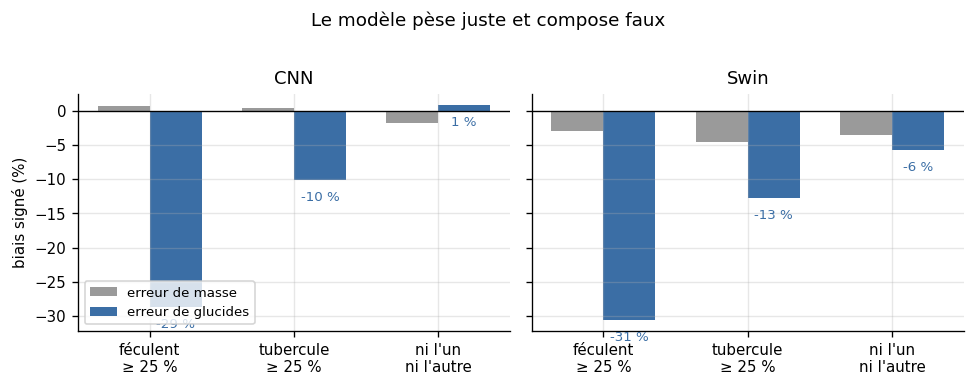

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.1), sharey=True)
for ax, bb, df in zip(axes, ("CNN", "Swin"), (cnn, swin)):
    labs = ["féculent\n≥ 25 %", "tubercule\n≥ 25 %", "ni l'un\nni l'autre"]
    em = [s.err_mass.mean() / s.true_mass.mean() * 100 for _, s in strates(df)]
    ec = [s.err.mean() / s.true_carb.mean() * 100 for _, s in strates(df)]
    x = np.arange(3); w = .36
    ax.bar(x - w/2, em, w, label="erreur de masse", color=GREY)
    ax.bar(x + w/2, ec, w, label="erreur de glucides", color=BLUE)
    for xi, v in zip(x + w/2, ec):
        ax.text(xi, v - 1.6, f"{v:.0f} %", ha="center", va="top", fontsize=8, color=BLUE)
    ax.axhline(0, color="k", lw=.8)
    ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_title(bb)
axes[0].set_ylabel("biais signé (%)"); axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Le modèle pèse juste et compose faux", y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

### 1.1 Ce n'est pas la régression vers la moyenne

Les plats à féculent sont riches en glucides (37 g contre 20 g en moyenne), et le modèle rabat déjà
toute valeur élevée vers la moyenne (pente de 0,78 dans le papier). Il faut donc écarter ce
confondant. Deux tests indépendants :

**Test de régression.** On régresse le biais signé sur la teneur vraie en glucides *et* la part de
féculent. Si le coefficient de la part de féculent survit, l'effet n'est pas réductible à la
régression vers la moyenne.

**Test d'appariement.** Chaque plat à féculent est apparié au plat sans féculent le plus proche en
teneur vraie en glucides. À teneur égale, les biais doivent coïncider si seule la régression vers la
moyenne opère.

In [7]:
def reg_table(df, cols):
    X = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    b, *_ = np.linalg.lstsq(X, df.err.values, rcond=None)
    r = df.err.values - X @ b
    se = np.sqrt(np.diag(np.linalg.pinv(X.T @ X)) * (r @ r / (len(df) - X.shape[1])))
    return pd.DataFrame({"terme": ["(const)"] + cols, "beta": b, "SE": se, "t": b / se})

print("CNN — biais glucides ~ teneur vraie + part de féculent + part de tubercule")
display(reg_table(cnn, ["true_carb", "part_feculent", "part_tubercule"]).round(3))

CNN — biais glucides ~ teneur vraie + part de féculent + part de tubercule


,terme,beta,SE,t
0,(const),3.251,0.377,8.623
1,true_carb,-0.199,0.015,-13.411
2,part_feculent,-9.346,1.559,-5.993
3,part_tubercule,-1.121,1.659,-0.676


In [8]:
def appariement(df, seuil=.25, seed=0):
    hi, lo = df[df.part_feculent >= seuil], df[df.part_feculent == 0]
    used, pairs = set(), []
    for _, row in hi.iterrows():
        cand = lo[~lo.index.isin(used)]
        if not len(cand):
            break
        j = (cand.true_carb - row.true_carb).abs().idxmin()
        used.add(j); pairs.append((row.err, lo.loc[j, "err"], row.true_carb, lo.loc[j, "true_carb"]))
    p = np.array(pairs); d = p[:, 0] - p[:, 1]
    rng = np.random.default_rng(seed)
    bs = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(10000)]
    return dict(n=len(p), carb_fec=p[:, 2].mean(), carb_tem=p[:, 3].mean(),
                biais_fec=p[:, 0].mean(), biais_tem=p[:, 1].mean(), ecart=d.mean(),
                ic_bas=np.percentile(bs, 2.5), ic_haut=np.percentile(bs, 97.5),
                p_wilcoxon=stats.wilcoxon(p[:, 0], p[:, 1]).pvalue)

display(pd.DataFrame([{"backbone": bb, **appariement(df)} for bb, df in (("CNN", cnn), ("Swin", swin))]).round(4))

,backbone,n,carb_fec,carb_tem,biais_fec,biais_tem,ecart,ic_bas,ic_haut,p_wilcoxon
0,CNN,33,37.6271,37.7461,-10.8034,-3.2259,-7.5774,-12.0320,-2.9829,0.0009
1,Swin,33,37.6271,37.7461,-11.5155,-4.4498,-7.0656,-11.0056,-3.0262,0.0015


L'appariement est quasi parfait sur la teneur en glucides (37 g contre 37 g), et pourtant l'écart de
biais reste de l'ordre de −8 g, hautement significatif. L'anomalie des féculents n'est **pas** un
effet de la régression vers la moyenne.

### 1.2 Spécificité : les autres types denses ne montrent pas l'effet

In [9]:
def appariement_type(df, t, seuil=.25):
    sh = np.array([TYPE_G[x].get(t, 0.0) for x in df.dish_id]) / df.true_mass.values
    d2 = df.assign(part=sh)
    hi, lo = d2[d2.part >= seuil], d2[d2.part == 0]
    if len(hi) < 8:
        return None
    used, pairs = set(), []
    for _, row in hi.iterrows():
        cand = lo[~lo.index.isin(used)]
        if not len(cand):
            break
        j = (cand.true_carb - row.true_carb).abs().idxmin()
        used.add(j); pairs.append((row.err, lo.loc[j, "err"]))
    p = np.array(pairs)
    return dict(type=t, n=len(p), biais=p[:, 0].mean(), temoin=p[:, 1].mean(),
                ecart=(p[:, 0] - p[:, 1]).mean(), p_wilcoxon=stats.wilcoxon(p[:, 0], p[:, 1]).pvalue)

spec = [r for t in ["feculent", "tubercule", "pizza", "fruit", "noix_graine", "legume"]
        if (r := appariement_type(cnn, t))]
display(pd.DataFrame(spec).round(4))

,type,n,biais,temoin,ecart,p_wilcoxon
0,feculent,33,-10.8034,-3.2259,-7.5774,0.0009
1,tubercule,31,-2.8180,-4.1995,1.3815,0.4214
2,pizza,41,-4.8313,-6.7155,1.8842,0.2160
3,fruit,146,-1.1261,-2.2966,1.1705,0.1116
4,noix_graine,27,-0.6911,-2.7244,2.0334,0.3865
5,legume,181,-0.5290,-0.8019,0.2729,0.2491


### 1.3 Le biais est stable sur les 32 variantes et les 5 graines

Le plan factoriel du papier compte 32 variantes (2 dorsales × 2 profondeurs × 4 alignements FLAVA
× 2 têtes). Si le biais des féculents était un accident d'entraînement, il varierait d'une variante à
l'autre.

In [10]:
def biais(df, part="part_feculent", seuil=.25):
    m = df[part] >= seuil
    return df[m].err.mean() / df[m].true_carb.mean() * 100

fact = []
for bb in ("CNN", "Swin"):
    for v in FACTORIEL:
        d = load(v, bb)
        fact.append({"backbone": bb, "variante": v,
                     "feculent": biais(d), "tubercule": biais(d, "part_tubercule")})
fact = pd.DataFrame(fact)
print(fact.groupby("backbone")[["feculent", "tubercule"]]
        .agg(["mean", "min", "max"]).round(1).to_string())
print(f"\nbiais féculent < biais tubercule dans {(fact.feculent < fact.tubercule).sum()}/{len(fact)} variantes")

print(f"\nmoyenne sur les 32 variantes : féculent {fact.feculent.mean():+.1f} % "
      f"(σ {fact.feculent.std(ddof=1):.1f}) | tubercule {fact.tubercule.mean():+.1f} % "
      f"(σ {fact.tubercule.std(ddof=1):.1f})")

         feculent             tubercule           
             mean   min   max      mean   min  max
backbone                                          
CNN         -27.4 -30.0 -25.0     -10.1 -11.9 -7.6
Swin        -28.2 -30.6 -26.2      -9.5 -13.5 -4.3

biais féculent < biais tubercule dans 32/32 variantes

moyenne sur les 32 variantes : féculent -27.8 % (σ 1.4) | tubercule -9.8 % (σ 2.0)


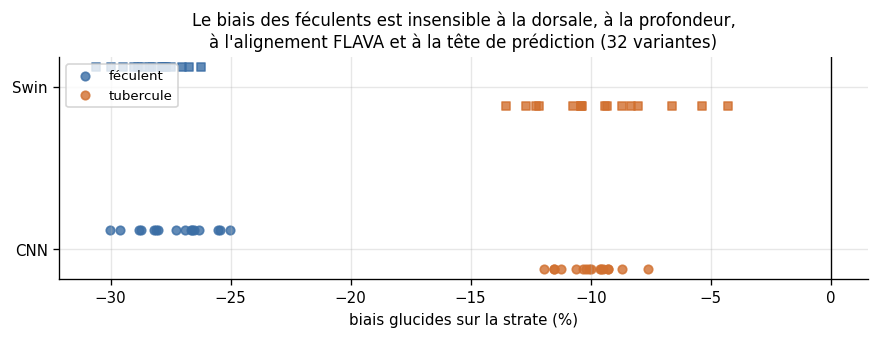

In [11]:
fig, ax = plt.subplots(figsize=(7.4, 2.9))
for i, (bb, mk) in enumerate((("CNN", "o"), ("Swin", "s"))):
    f = fact[fact.backbone == bb]
    ax.scatter(f.feculent, np.full(len(f), i + .12), marker=mk, s=26, color=BLUE, alpha=.8,
               label="féculent" if i == 0 else None)
    ax.scatter(f.tubercule, np.full(len(f), i - .12), marker=mk, s=26, color=ORANGE, alpha=.8,
               label="tubercule" if i == 0 else None)
ax.axvline(0, color="k", lw=.8)
ax.set_yticks([0, 1]); ax.set_yticklabels(["CNN", "Swin"])
ax.set_xlabel("biais glucides sur la strate (%)")
ax.set_title("Le biais des féculents est insensible à la dorsale, à la profondeur,\n"
             "à l'alignement FLAVA et à la tête de prédiction (32 variantes)", fontsize=10)
ax.legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

---
## 2. L'échelle d'information restreinte aux plats à féculent

C'est le résultat qui change l'interprétation. Le papier compare le modèle visuel à des prédicteurs
*sans image* recevant de plus en plus d'information :

- **P0** — rien (constante) ;
- **P1** — identité des ingrédients, sans les quantités ;
- **P1b** — identité + masse totale vraie ;
- **P2** — masses vraies *par ingrédient*.

Si le biais des féculents était un défaut de la vision, il devrait être absent de ces prédicteurs
aveugles. On le mesure donc sur chacun d'eux.

> **Seule entorse au périmètre du § 0.** Les baselines n'ont été produites que sur 497 plats.
> Cette section aligne donc modèle visuel et baselines sur leurs plats communs, **à l'identique pour
> CNN et pour Swin**. Les baselines ne dépendent d'aucune dorsale — `baseline_prior.py` n'utilise ni
> image ni backbone — ce sont donc bien les mêmes quatre références pour les deux colonnes.

In [12]:
def load_baseline(fname):
    df = pd.read_csv(BASE / fname)
    sh = np.array([TYPE_G[x].get("feculent", 0.0) for x in df.dish_id]) / df.true_mass.values
    return df.assign(part_feculent=sh, err=df.pred_carb - df.true_carb,
                     abserr=(df.pred_carb - df.true_carb).abs())

BASELINES = [("P0 — rien (constante)",         load_baseline("prior_mean_mean.csv")),
             ("P1 — identité des ingrédients", load_baseline("prior_presence_mlp.csv")),
             ("P1b — identité + masse totale (passthrough)", load_baseline("prior_presence_passthrough_truemass.csv")),
             ("P2 — masses par ingrédient",    load_baseline("prior_mass_linear.csv"))]

# Plats communs aux baselines et au factoriel : même restriction pour les deux dorsales.
COMMUNS = set(BASELINES[0][1].dish_id)
print(f"baselines : {len(COMMUNS)} plats | factoriel : {len(cnn)} plats | "
      f"baselines incluses dans le factoriel : {COMMUNS <= set(cnn.dish_id)}")

def sur_communs(df):
    return df[df.dish_id.isin(COMMUNS)].reset_index(drop=True)

m_fec = (sur_communs(cnn).part_feculent >= .25).values
rows = []
for lab, d in ([("Modèle visuel — CNN", sur_communs(cnn)), ("Modèle visuel — Swin", sur_communs(swin))]
               + [(l, sur_communs(b)) for l, b in BASELINES]):
    rows.append({"niveau d'information": lab,
                 "PMAE glucides (tous)": d.abserr.mean() / d.true_carb.mean() * 100
                 if "abserr" in d else pmae(d),
                 "PMAE glucides (féculent)": d[m_fec].abserr.mean() / d[m_fec].true_carb.mean() * 100
                 if "abserr" in d else pmae(d[m_fec]),
                 "biais (féculent) %": d[m_fec].err.mean() / d[m_fec].true_carb.mean() * 100})
echelle = pd.DataFrame(rows)
ORDRE = ["P0 — rien (constante)", "P1 — identité des ingrédients", "Modèle visuel — CNN",
         "Modèle visuel — Swin", "P1b — identité + masse totale (passthrough)", "P2 — masses par ingrédient"]
echelle = echelle.set_index("niveau d'information").loc[ORDRE].reset_index()
display(echelle.round(1))

baselines : 497 plats | factoriel : 507 plats | baselines incluses dans le factoriel : True


,niveau d'information,PMAE glucides (tous),PMAE glucides (féculent),biais (féculent) %
0,P0 — rien (constante),69.5,50.8,-48.5
1,P1 — identité des ingrédients,38.2,46.7,-43.8
2,Modèle visuel — CNN,19.6,30.0,-27.6
3,Modèle visuel — Swin,19.9,33.2,-30.6
4,P1b — identité + masse totale (passthrough),17.0,23.4,-20.5
5,P2 — masses par ingrédient,1.8,1.8,-1.7


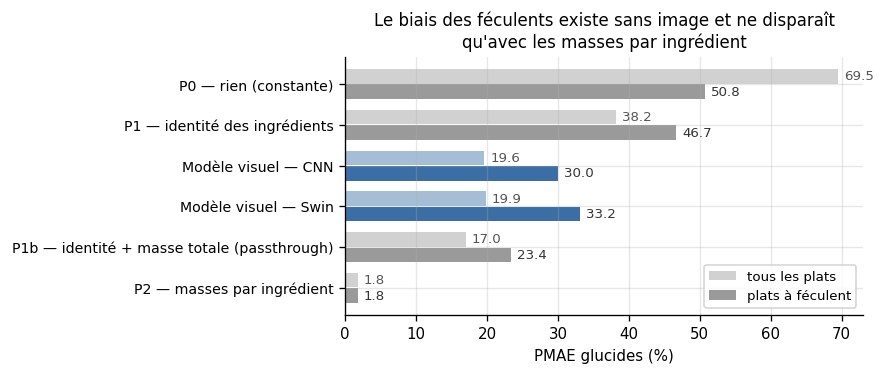

In [13]:
fig, ax = plt.subplots(figsize=(7.4, 3.2))
y = np.arange(len(echelle))[::-1]
coul = [BLUE if "visuel" in l else GREY for l in echelle["niveau d'information"]]
ax.barh(y + .19, echelle["PMAE glucides (tous)"], .36, color=coul, alpha=.45,
        label="tous les plats")
ax.barh(y - .19, echelle["PMAE glucides (féculent)"], .36, color=coul,
        label="plats à féculent")
for yi, a, b in zip(y, echelle["PMAE glucides (tous)"], echelle["PMAE glucides (féculent)"]):
    ax.text(a + .8, yi + .19, f"{a:.1f}", va="center", fontsize=8, color="#555")
    ax.text(b + .8, yi - .19, f"{b:.1f}", va="center", fontsize=8, color="#333")
ax.set_yticks(y); ax.set_yticklabels(echelle["niveau d'information"], fontsize=8.5)
ax.set_xlabel("PMAE glucides (%)")
ax.set_title("Le biais des féculents existe sans image et ne disparaît\nqu'avec les masses par ingrédient",
             fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**Lecture.** Le biais est présent chez tous les prédicteurs aveugles — jusqu'à −48 % pour P0,
encore −20,5 % pour P1b qui connaît pourtant les ingrédients *et* la masse totale vraie — et il
s'effondre à −2 % dès qu'on fournit les masses **par ingrédient** (P2).

Ce n'est donc pas une défaillance de la vision ni de l'architecture : c'est la signature, sur une
classe d'aliments identifiable, de l'information exacte qui manque. Savoir « il y a du riz » et
« l'assiette pèse 250 g » ne dit pas combien de grammes sont du riz ; la distribution conditionnelle
étant asymétrique, tout prédicteur optimal en erreur absolue sous-estime.

Sur ces plats, les deux dorsales (30–33 %) font **moins bien que P1b** (23 %) : connaître la masse
*totale* vraie aide déjà beaucoup — un gros tas pèse lourd — et le modèle visuel, lui, doit encore
l'estimer. Mais même P1b, qui reçoit l'identité **et** la masse totale exacte, sous-estime toujours
de 20 % : seules les masses **par ingrédient** (P2) lèvent l'ambiguïté. Le modèle visuel se situe
ainsi entre P1 (identité seule) et P1b (identité + masse totale). La strate ne comptant que 32 plats,
cet écart est à présenter comme une tendance, pas comme une preuve — d'où la vérification de
stabilité au seuil ci-dessous.

In [14]:
P1b = sur_communs(load_baseline("prior_presence_passthrough_truemass.csv"))
vc, vs = sur_communs(cnn), sur_communs(swin)
sens = []
for th in (.10, .15, .20, .25, .30, .40):
    mm = (vc.part_feculent >= th).values
    sens.append({"seuil": th, "n": int(mm.sum()),
                 "visuel CNN": vc[mm].abserr.mean() / vc[mm].true_carb.mean() * 100,
                 "visuel Swin": vs[mm].abserr.mean() / vs[mm].true_carb.mean() * 100,
                 "P1b": P1b[mm].abserr.mean() / P1b[mm].true_carb.mean() * 100})
display(pd.DataFrame(sens).round({"seuil": 2, "n": 0, "visuel CNN": 1, "visuel Swin": 1, "P1b": 1}))

,seuil,n,visuel CNN,visuel Swin,P1b
0,0.10,71,29.8,31.4,20.8
1,0.15,47,30.1,33.7,23.3
2,0.20,40,30.5,33.6,24.0
3,0.25,32,30.0,33.2,23.4
4,0.30,29,26.9,30.4,18.1
5,0.40,18,35.7,34.1,16.9


---
## 3. Le gradient composition / portion

Le papier décompose exactement l'erreur d'un nutriment par plat (Éq. 2), avec $d$ la densité par
100 g et $m$ la masse, les indices $p$ et $t$ désignant le prédit et le vrai :

$$\underbrace{d_p m_p - d_t m_t}_{\text{erreur totale}}
= \underbrace{m_t\,(d_p - d_t)}_{\text{composition}}
+ \underbrace{d_p\,(m_p - m_t)}_{\text{portion}}$$

Le terme *composition* isole l'erreur de densité à portion tenue vraie, le terme *portion* isole
l'erreur de masse à composition tenue prédite. Le papier rapporte un poids global de 64 % / 36 %.
On le recalcule **par strate de complexité**, sur les variantes à tête densité des deux dorsales.

Comme annoncé au § 0, les densités sont reconstruites depuis les colonnes standard
($d = 100\,c/m$), ce qui rend la section calculable à l'identique côté CNN et côté Swin.

In [15]:
def decomposition(stem, backbone):
    d = load(stem, backbone)
    dp = d.pred_carb / d.pred_mass * 100      # densité prédite reconstruite
    dt = d.true_carb / d.true_mass * 100      # densité vraie
    return d.assign(e_comp=d.true_mass * (dp - dt) / 100,
                    e_port=dp * (d.pred_mass - d.true_mass) / 100)

STRATES = [("1 ingrédient", lambda d: d.n_ingr == 1),
           ("2–4",          lambda d: (d.n_ingr > 1) & (d.n_ingr <= 4)),
           ("5–10",         lambda d: (d.n_ingr > 4) & (d.n_ingr <= 10)),
           ("11 et +",      lambda d: d.n_ingr > 10),
           ("tous",         lambda d: d.n_ingr > 0)]

grad = {}
for bb in ("CNN", "Swin"):
    d = decomposition("fusion_gt_all_d_best", bb)
    grad[bb] = {lab: (lambda s: s.e_comp.abs().mean() /
                      (s.e_comp.abs().mean() + s.e_port.abs().mean()) * 100)(d[f(d)])
                for lab, f in STRATES}
n_par_strate = {lab: int(f(decomposition("fusion_gt_all_d_best", "CNN")).sum()) for lab, f in STRATES}
tab3 = pd.DataFrame(grad).assign(n=pd.Series(n_par_strate))
display(tab3.round(0))

d = decomposition("fusion_gt_all_d_best", "CNN"); mc = d.true_carb.mean()
print(f"\nCNN, contrôle global : total {(d.e_comp + d.e_port).abs().mean()/mc*100:.1f} %  |  "
      f"composition seule {d.e_comp.abs().mean()/mc*100:.1f} %  |  "
      f"portion seule {d.e_port.abs().mean()/mc*100:.1f} %")

,CNN,Swin,n
1 ingrédient,55.0,49.0,161
2–4,59.0,59.0,111
5–10,69.0,70.0,99
11 et +,70.0,66.0,136
tous,64.0,62.0,507



CNN, contrôle global : total 21.0 %  |  composition seule 17.8 %  |  portion seule 10.1 %


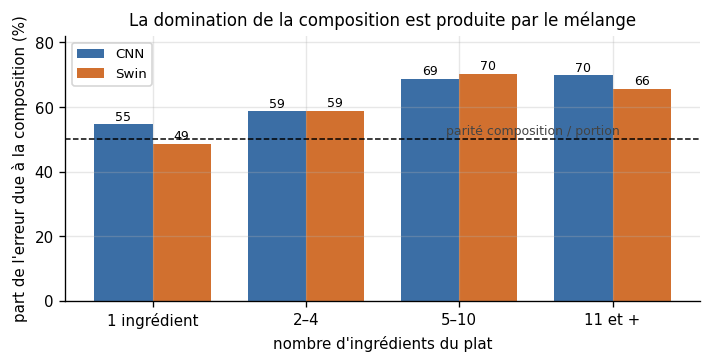

In [16]:
fig, ax = plt.subplots(figsize=(6.0, 3.1))
labs = [l for l, _ in STRATES if l != "tous"]
x = np.arange(len(labs)); w = .38
for i, (bb, c) in enumerate((("CNN", BLUE), ("Swin", ORANGE))):
    v = [grad[bb][l] for l in labs]
    ax.bar(x + (i - .5) * w, v, w, color=c, label=bb)
    for xi, vi in zip(x + (i - .5) * w, v):
        ax.text(xi, vi + 1.2, f"{vi:.0f}", ha="center", fontsize=7.5)
ax.axhline(50, color="k", ls="--", lw=.9)
ax.text(3.05, 51.5, "parité composition / portion", fontsize=7.5, color="#444", ha="right")
ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylim(0, 82); ax.set_ylabel("part de l'erreur due à la composition (%)")
ax.set_xlabel("nombre d'ingrédients du plat")
ax.set_title("La domination de la composition est produite par le mélange", fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Sur un plat **mono-ingrédient**, l'erreur est majoritairement une erreur de *portion* : la composition
est déterminée dès que l'aliment est reconnu. La part composition croît ensuite nettement sur les
plats composés, et les deux dorsales décrivent le même gradient. Le chiffre global du papier est donc
la moyenne d'un gradient : la domination de la composition n'est pas une propriété de la tâche, mais
une propriété des plats mélangés.

---
## 4. La compression opère au niveau des types d'aliments

Le papier observe une pente prédiction/vérité de 0,78 sur les glucides (contre 0,93 sur la masse) et
montre qu'elle est optimale face à l'incertitude. On cherche ici *où* cette compression est
implémentée.

On régresse les glucides prédits sur les grammes de chaque type présents dans le plat. Le coefficient
du type $k$ s'interprète comme la **densité glucidique implicite** (g de glucides pour 100 g de ce
type) que le modèle lui applique. La même régression sur les glucides *vrais* donne la densité réelle.

Une régression ridge est nécessaire — les types co-apparaissent fortement — et on se restreint aux
types bien estimés (≥ 30 plats et ≥ 1 kg cumulé) : sur les types rares, les coefficients OLS
explosent et faussent la pente. La stabilité OLS/ridge est vérifiée juste après.

In [17]:
X = np.array([[TYPE_G[x].get(t, 0.0) for t in TYPES] for x in cnn.dish_id]) / 100.0
solide = [k for k in range(len(TYPES)) if (X[:, k] > 0).sum() >= 30 and X[:, k].sum() * 100 >= 1000]
d_vrai = Ridge(alpha=1).fit(X, cnn.true_carb.values).coef_

dens = pd.DataFrame({"type": [TYPES[k] for k in solide], "densité vraie": d_vrai[solide]})
pentes = {}
for bb, df in (("CNN", cnn), ("Swin", swin)):
    b = Ridge(alpha=1).fit(X, df.pred_carb.values).coef_
    dens[f"modèle {bb}"] = b[solide]
    dens[f"écart {bb}"] = b[solide] - d_vrai[solide]
    o = LinearRegression().fit(X, df.pred_carb.values).coef_
    pentes[bb] = (stats.linregress(d_vrai[solide], b[solide]).slope,
                  stats.linregress(d_vrai[solide], o[solide]).slope)
display(dens.sort_values("densité vraie", ascending=False).round(1))
for bb, (r, o) in pentes.items():
    print(f"pente de compression {bb:5s} : {r:.3f} (ridge) | {o:.3f} (OLS)")
print("à comparer à la pente de sortie du papier : 0,78 (glucides) contre 0,93 (masse)")

,type,densité vraie,modèle CNN,écart CNN,modèle Swin,écart Swin
8,pizza,31.0,26.5,-4.5,26.3,-4.7
1,feculent,25.0,13.8,-11.1,14.2,-10.8
6,noix_graine,23.5,21.7,-1.8,20.3,-3.2
10,tubercule,18.7,15.5,-3.3,15.0,-3.7
2,fruit,11.6,10.5,-1.1,10.4,-1.2
3,laitier,9.4,7.5,-1.9,7.5,-1.9
5,legumineuse,8.0,8.3,0.3,8.3,0.3
4,legume,7.4,6.6,-0.8,5.8,-1.6
9,sauce_condiment,5.6,1.5,-4.1,2.1,-3.5
0,autre,0.8,9.9,9.1,5.3,4.5


pente de compression CNN   : 0.688 (ridge) | 0.718 (OLS)
pente de compression Swin  : 0.724 (ridge) | 0.762 (OLS)
à comparer à la pente de sortie du papier : 0,78 (glucides) contre 0,93 (masse)


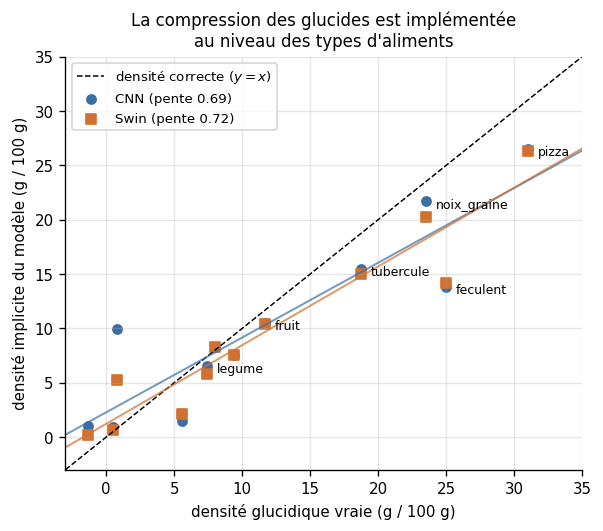

In [18]:
fig, ax = plt.subplots(figsize=(5.1, 4.5))
lim = [-3, 35]
ax.plot(lim, lim, "--", color="k", lw=.9, label="densité correcte ($y = x$)")
for bb, c, mk in (("CNN", BLUE, "o"), ("Swin", ORANGE, "s")):
    yv = dens[f"modèle {bb}"].values; xv = dens["densité vraie"].values
    ax.scatter(xv, yv, color=c, marker=mk, s=30, label=f"{bb} (pente {pentes[bb][0]:.2f})")
    sl, ic = stats.linregress(xv, yv)[:2]
    ax.plot(lim, [sl * v + ic for v in lim], color=c, lw=1.2, alpha=.7)
for _, r in dens.iterrows():
    if r["type"] in ("feculent", "pizza", "tubercule", "noix_graine", "fruit", "legume"):
        ax.annotate(r["type"], (r["densité vraie"], r["modèle CNN"]),
                    textcoords="offset points", xytext=(6, -4), fontsize=7.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("densité glucidique vraie (g / 100 g)")
ax.set_ylabel("densité implicite du modèle (g / 100 g)")
ax.set_title("La compression des glucides est implémentée\nau niveau des types d'aliments", fontsize=10)
ax.legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

Les types denses sont tirés vers le bas et les types pauvres légèrement vers le haut : la pente
mesurée sur l'échelle des densités reproduit de près la pente de sortie de 0,78 du papier, et les
deux dorsales donnent la même valeur. Le féculent est le point le plus éloigné de la diagonale.

---
## 5. Le nombre d'ingrédients est un faux coupable

L'explication qui vient spontanément à l'esprit est « le modèle se trompe quand il y a beaucoup
d'ingrédients ». La corrélation brute semble d'ailleurs la confirmer. Mais le nombre d'ingrédients
est corrélé à la masse totale, et les gros plats portent mécaniquement des erreurs absolues plus
grandes.

On compare donc trois descripteurs dans une même régression standardisée : la masse, le nombre
d'ingrédients, et la **dispersion des densités** — l'écart-type, pondéré par la masse, des densités
glucidiques des ingrédients du plat :

$$\sigma_d \;=\; \sqrt{\textstyle\sum_i w_i\,(d_i - \bar d)^2},
\qquad w_i = \frac{g_i}{\sum_j g_j},\qquad \bar d = \textstyle\sum_i w_i d_i$$

Elle vaut zéro pour un plat homogène (le total se déduit alors de la masse) et croît lorsque le plat
mélange des ingrédients de densités très différentes — cas où le total dépend de la répartition des
grammes, précisément l'information absente.

In [19]:
print("corrélations brutes de Spearman avec |erreur glucides| :")
for c in ("n_ingr", "true_mass", "disp"):
    v = [f"{bb} {stats.spearmanr(df[c], df.abserr).statistic:+.3f}"
         for bb, df in (("CNN", cnn), ("Swin", swin))]
    print(f"  {c:10s} rho = {'  |  '.join(v)}")

out = []
for bb, d in (("CNN", cnn), ("Swin", swin)):
    Z = np.column_stack([np.ones(len(d))] + [(d[c] - d[c].mean()) / d[c].std()
                                             for c in ("true_mass", "n_ingr", "disp")])
    b, *_ = np.linalg.lstsq(Z, d.abserr.values, rcond=None)
    r = d.abserr.values - Z @ b
    se = np.sqrt(np.diag(np.linalg.pinv(Z.T @ Z)) * (r @ r / (len(d) - 4)))
    for i, nom in enumerate(["masse", "nombre d'ingrédients", "dispersion des densités"], start=1):
        out.append({"dorsale": bb, "terme": nom, "beta (standardisé)": b[i], "t": b[i] / se[i]})
display(pd.DataFrame(out).round(3))

corrélations brutes de Spearman avec |erreur glucides| :
  n_ingr     rho = CNN +0.239  |  Swin +0.293
  true_mass  rho = CNN +0.419  |  Swin +0.499
  disp       rho = CNN +0.326  |  Swin +0.409


,dorsale,terme,beta (standardisé),t
0,CNN,masse,1.036,3.871
1,CNN,nombre d'ingrédients,-0.637,-2.124
2,CNN,dispersion des densités,1.890,6.407
3,Swin,masse,1.553,6.098
4,Swin,nombre d'ingrédients,-0.766,-2.685
5,Swin,dispersion des densités,2.122,7.559


Une fois la masse et la dispersion prises en compte, le coefficient du nombre d'ingrédients devient
**négatif** sur les deux dorsales : à masse et hétérogénéité égales, un plat plus composé est *mieux*
prédit. La corrélation brute était entièrement un effet de masse. La variable qui porte réellement le
signal est la dispersion des densités — un descripteur calculable *a priori*, sans modèle.

---
## 6. Ce qui est retenu pour l'article

| § | Résultat | Robustesse |
|---|---|---|
| 1–2 | **Anomalie des féculents** : le modèle pèse juste et compose faux ; le biais existe sans image (P1b) et ne disparaît qu'avec les masses par ingrédient (P2) | 32/32 variantes du plan factoriel, les deux dorsales |
| 3 | **Gradient composition/portion** : la domination de la composition est produite par le mélange | les deux dorsales, même gradient |
| 4 | **Compression au niveau des types** : mécanisme de la pente de 0,78 | les deux dorsales ; stable OLS/ridge |
| 5 | **Le nombre d'ingrédients est un faux coupable** | les deux dorsales |

### Périmètre et limites

**Un run unique par variante.** Ce notebook n'utilise ni les campagnes multi-graines (CNN seulement)
ni les fichiers `_filtered` (Swin seulement), afin que les deux dorsales soient traitées exactement
de la même façon. La robustesse ne vient donc pas de la répétition d'un même entraînement mais de la
**réplication sur 32 entraînements indépendants** du plan factoriel. Si l'on souhaite des barres
d'erreur au sens du papier, les graines CNN existent et peuvent être ajoutées — mais elles n'ont
alors pas d'équivalent Swin.

**Test complet, n = 507.** Les tableaux du papier portent sur le test filtré (n = 497) ; les valeurs
d'ici sont donc environ 0,5 point plus hautes. Les conclusions sont inchangées — le § 1 vérifie
d'ailleurs la stabilité du résultat principal sur plusieurs seuils de définition de la strate.

**32 plats dans la strate des féculents.** C'est la principale faiblesse, compensée par la
réplication sur 32 variantes et par la stabilité entre les seuils de 10 % et 40 %.

**Taxonomie agrégée.** `feculent` regroupe riz, pâtes, pain et céréales, via une liste de mots-clés
fixée sans jamais consulter les erreurs du modèle. Séparer ces sous-classes reste à trancher.

**Identité de vérité terrain.** Les baselines P0–P2 utilisent les ingrédients annotés, pas un
reconnaisseur : elles bornent l'information disponible, elles ne constituent pas un système
déployable — même réserve que dans le papier.